Accuracy: 1.0
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00         1
     Average       1.00      1.00      1.00         2
        Good       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5

Predicted Class: Average


c:\Users\rajni\ml-lab\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


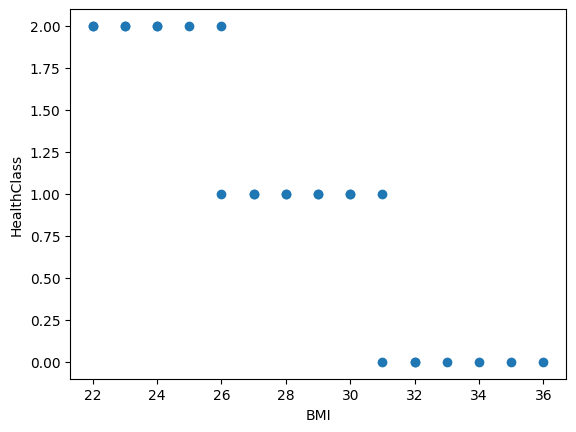

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("health_data.csv")

# Target
score = df["HealthScore"]
df["HealthClass"] = np.select(
    [score < 50, (score >= 50) & (score < 70), score >= 70],
    [0, 1, 2]
)

# Features / target
X = df[["Age","BMI","ExerciseHours"]]
y = df["HealthClass"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale + model
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

nb = GaussianNB()
nb.fit(X_train, y_train)

# Predict + evaluate
y_pred = nb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred,
      target_names=["Poor","Average","Good"]))

# Single prediction
labels = ["Poor","Average","Good"]
pred = nb.predict(scaler.transform([[35,26,3]]))[0]
print("Predicted Class:", labels[pred])

# Plot
plt.scatter(df["BMI"], df["HealthClass"])
plt.xlabel("BMI")
plt.ylabel("HealthClass")
plt.show()